In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Here I define column names to help there being no headers in the data.
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

df = pd.read_csv("adult.data", header=None, names=column_names, na_values=" ?", skipinitialspace=True)
df.head()



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


EDA: Exploratory Data Analysisation Heatmap')
plt.show()


In [13]:
#shape
print("Shape:", df.shape)

#shows data types
df.info()

# gives statistics of datasets in a summarized form
df.describe(include='all')

#displays values that are missing
df.isnull().sum()


Shape: (32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

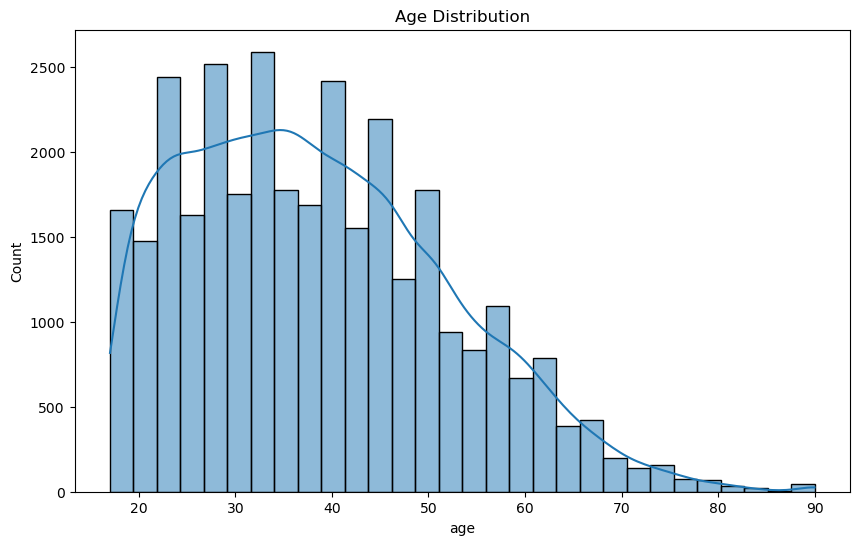

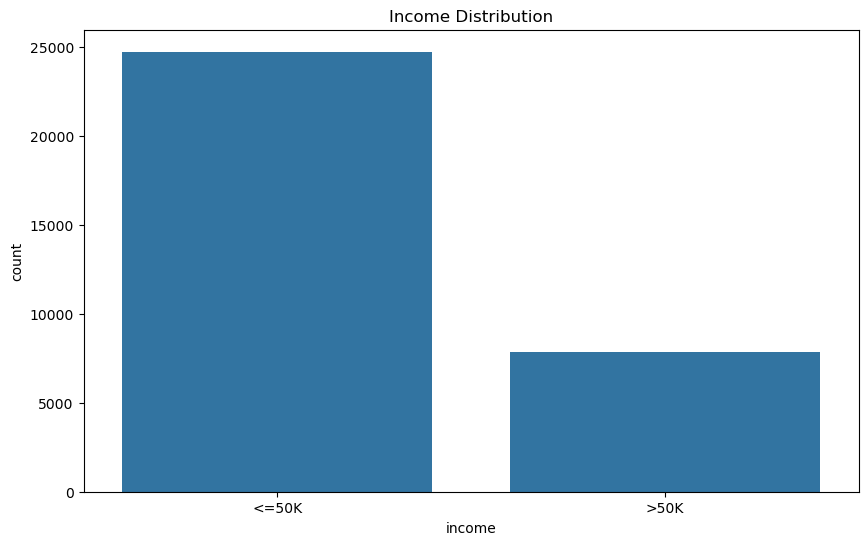

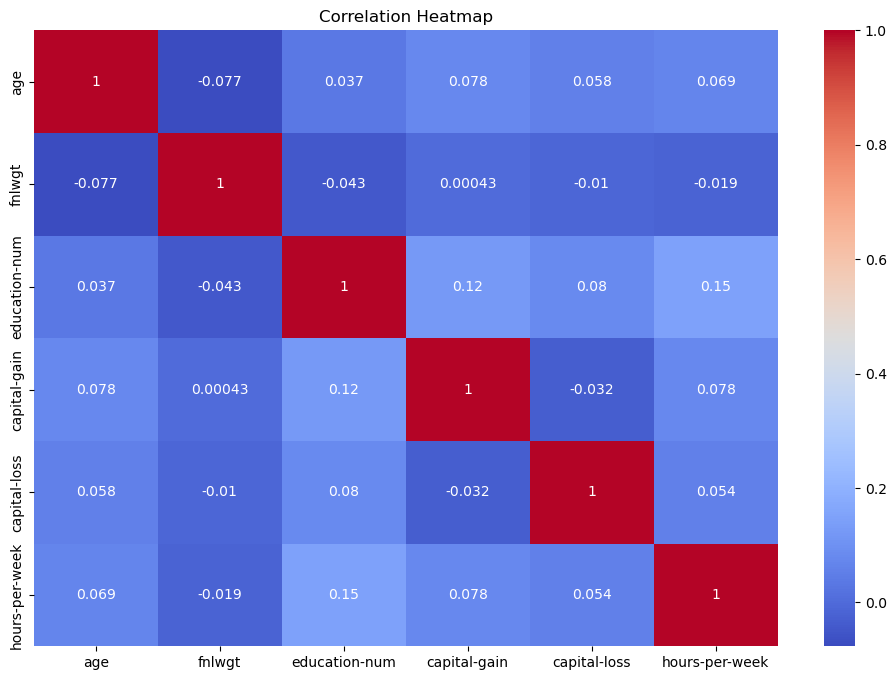

In [15]:
# Age distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()


# Income Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='income')
plt.title('Income Distribution')
plt.show()


# Correlation matrix/heatmap (numeric columns)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Plot 1:
This histogram shows a distribution of ages in the dataset, highlighting that most people are between 20 and 50 years old, with a peak from 30 to 35 years old. After reaching age 50, there is  a slow decline. This essentially shows that the dataset has a rightward skew, highlighting that there is less old individualds in the dataset. Moreover, most of the individuals in the dataset are of working age, which can have an impact on the results regarding income brackets.

Plot 2:
This bar chart compares how many people in the dataset earn more or less than 50 thousand dollars anually. Looking at the data, it can be seen that the datset itself is imbalanced, with more people being lower-income. This highlights a possible hypothesis to test (will cover later on). High income earners are a minority in the dataset.

Plot 3:
This hearmap shows correlations betweenn numerical features. Education-num has a positive correlation with hours per week and capital gain. Other correlations are weak, which may indicate that most of them are independent for the most part. Age shows a positive correlation with hours per week and capital gain. This indicates that people who are older have more gains or work more.

Hypotheses:

<b>Hypothesis 1: Education vs Income<b>
Individuals with higher educarion are more likley to earn more than 50 thousand dollars a year
This hypothesis was chosen from looking at the EDA and investigating current social trends. It is a commond idea that higher aducation is associated with having a higher paying job.

<b>Hypothesis 2: Gender vs Income<b>
If an indiduals gender is male, they are more likley to earn more than 50 thousand dollars anually compared to women
This hypothesis was chosen as it may reveal a wage gap present because of gender, which is a common point of issue in many countries/companies

<b>Hypothesis 3: Age vs Income<b>
Older peope are more likely to earn more than 50 thousand dollars anually
This hypothesis was chosen as income isuaully increases as a person has more experience or continues in their profession for longer, so higher age shoes correlate with a larger income.

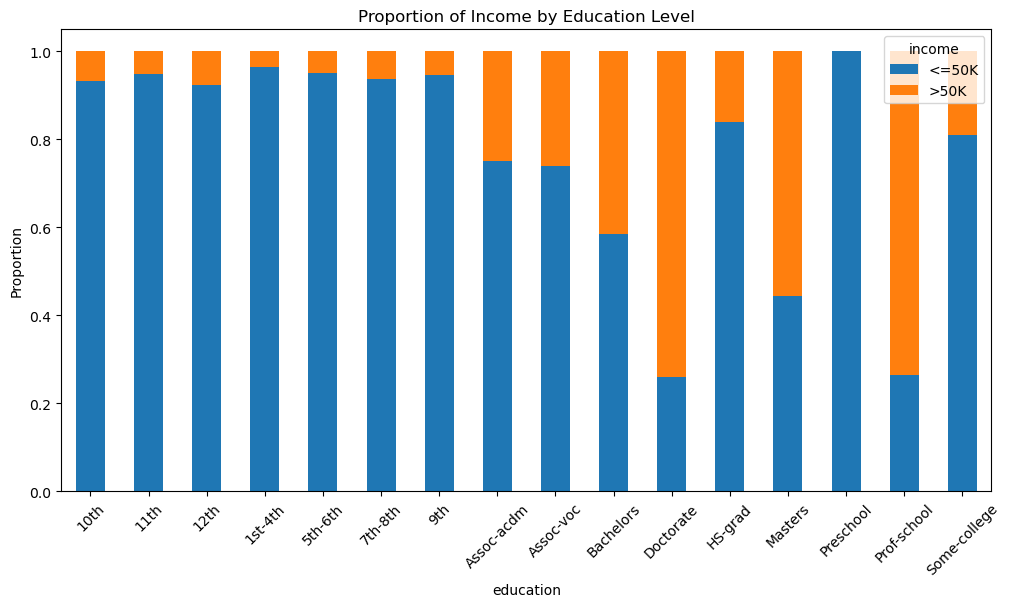

In [17]:
edu_income = pd.crosstab(df['education'], df['income'], normalize='index')
edu_income.plot(kind='bar', figsize=(12, 6), stacked=True)
plt.title("Proportion of Income by Education Level")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()


Testing Hypothesis 1:
There is a clear trend that shows that people who have higher educaition levels have a learger proportion of incomes larger than 50 thousand dollars. People who have high school or less almost entirely fall under 50 thousand a year. This anlaysis supports that higher education is associated with more income.

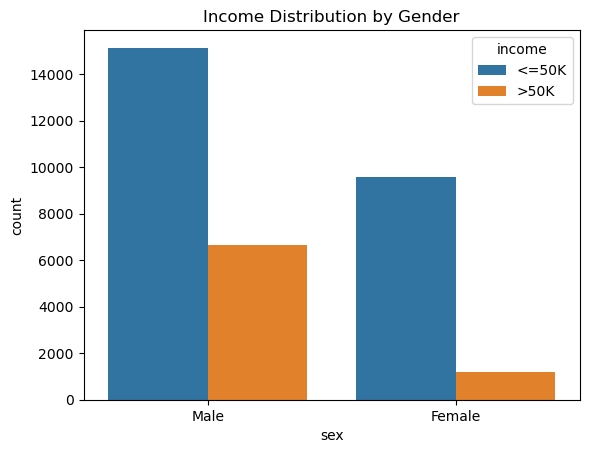

In [19]:
sns.countplot(data=df, x='sex', hue='income')
plt.title("Income Distribution by Gender")
plt.show()


Testing for Hypothesis 2:
This plot shows that males have a much higher amount of people who earn more than 50 thousand dollars a year compared to wfeamles. Although majority of both genders earn less than 50 thousand, the gender gap is here is clearly visible. This supports the hypothesis

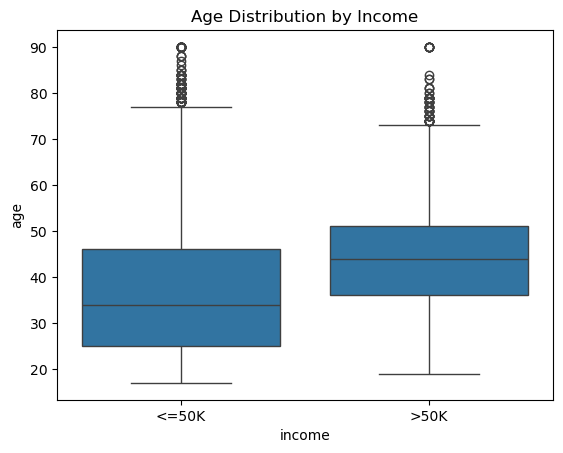

In [21]:
sns.boxplot(data=df, x='income', y='age')
plt.title("Age Distribution by Income")
plt.show()


Testing for Hypothesis 3:
The plot above indicates that people who earn more than 50 thousand a year tend to be older on average than individuals earning less than 50 thousand dollars per year. The higher income group contains more people in their 40s and 50s, while the lower income group has a skew of younger ages. This supports the hypothesis.